# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can plot the output, comparing signal and background:

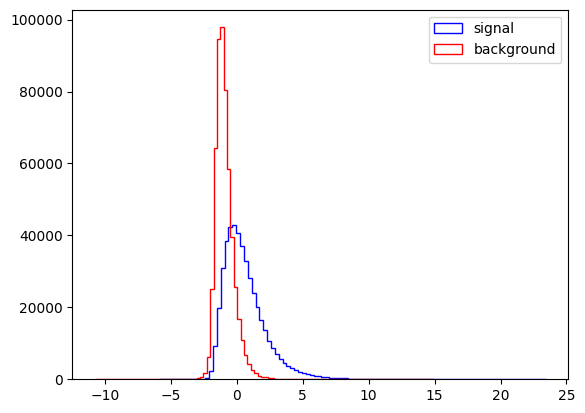

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

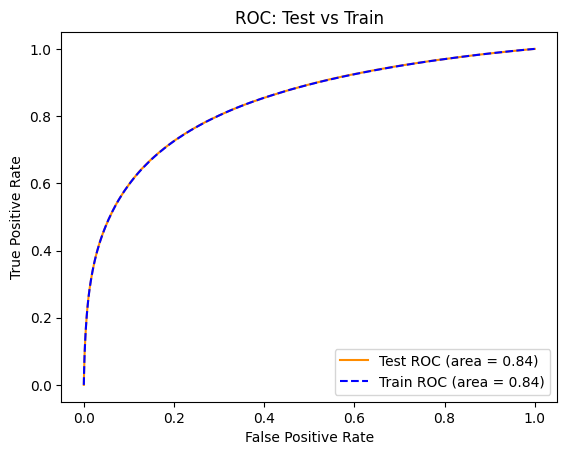

In [7]:
from sklearn.metrics import roc_curve, auc

# ROC on Test Sample
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# ROC on Train Sample
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# Plotting both
plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', label='Test ROC (area = %0.2f)' % auc_test)
plt.plot(fpr_train, tpr_train, color='blue', linestyle='--', label='Train ROC (area = %0.2f)' % auc_train)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC: Test vs Train')
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [8]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

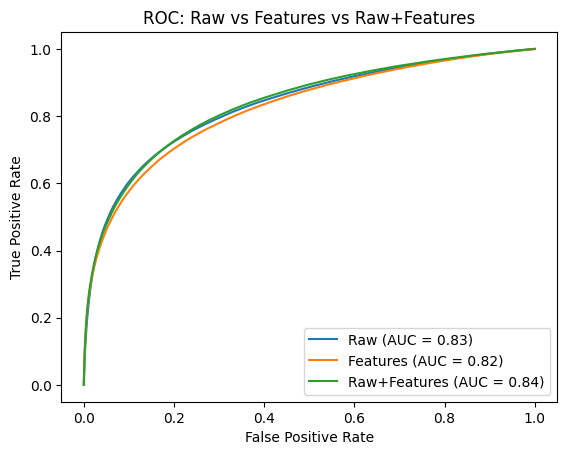

In [9]:
# Train 3 Fisher classifiers on different input sets
Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_raw.fit(X_Train[RawNames], y_Train)

Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_feat.fit(X_Train[FeatureNames], y_Train)

Fisher_all = DA.LinearDiscriminantAnalysis()
Fisher_all.fit(X_Train[VarNames[1:]], y_Train)

# Compute ROC curves
fpr_raw, tpr_raw, _ = roc_curve(y_Test, Fisher_raw.decision_function(X_Test[RawNames]))
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_feat.decision_function(X_Test[FeatureNames]))
fpr_all, tpr_all, _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test[VarNames[1:]]))

# Plot
plt.figure()
plt.plot(fpr_raw, tpr_raw, label='Raw (AUC = %0.2f)' % auc(fpr_raw, tpr_raw))
plt.plot(fpr_feat, tpr_feat, label='Features (AUC = %0.2f)' % auc(fpr_feat, tpr_feat))
plt.plot(fpr_all, tpr_all, label='Raw+Features (AUC = %0.2f)' % auc(fpr_all, tpr_all))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC: Raw vs Features vs Raw+Features')
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# classifier representation
nb = GaussianNB()
dt = DecisionTreeClassifier()
lr = LogisticRegression(max_iter=1000)

# Train each one
nb.fit(X_Train, y_Train)
dt.fit(X_Train, y_Train)
lr.fit(X_Train, y_Train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


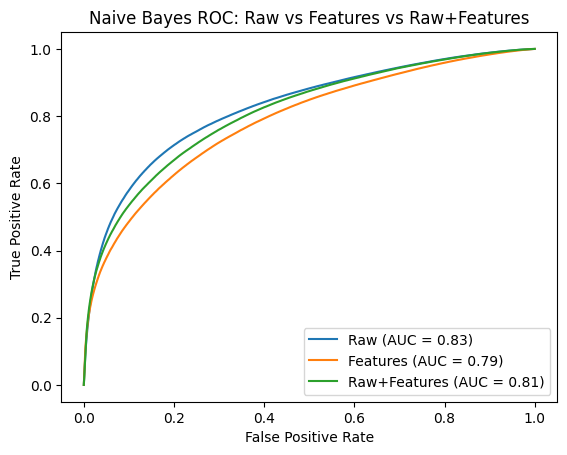

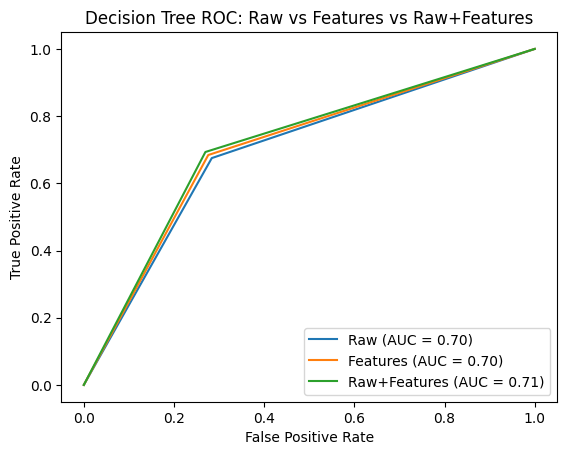

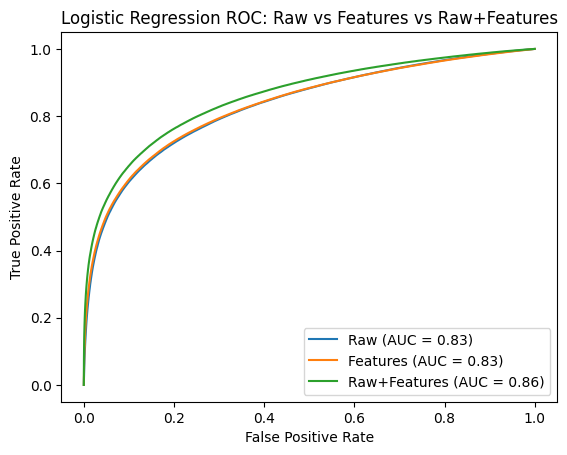

In [16]:
from sklearn.metrics import roc_curve, auc

# Use a subset for faster training
N_Sub = 500000
X_Train_sub = X_Train[:N_Sub]
y_Train_sub = y_Train[:N_Sub]

def compare_roc(clf, clf_name):
    # Train and plot ROC for raw, features, and raw+features inputs
    
    # Raw inputs
    clf.fit(X_Train_sub[RawNames], y_Train_sub)
    fpr_raw, tpr_raw, _ = roc_curve(y_Test, clf.predict_proba(X_Test[RawNames])[:,1])
    
    # Engineered features
    clf.fit(X_Train_sub[FeatureNames], y_Train_sub)
    fpr_feat, tpr_feat, _ = roc_curve(y_Test, clf.predict_proba(X_Test[FeatureNames])[:,1])
    
    # Both combined
    clf.fit(X_Train_sub[VarNames[1:]], y_Train_sub)
    fpr_all, tpr_all, _ = roc_curve(y_Test, clf.predict_proba(X_Test[VarNames[1:]])[:,1])
    
    # Plot all three on one figure
    plt.figure()
    plt.plot(fpr_raw, tpr_raw, label='Raw (AUC = %0.2f)' % auc(fpr_raw, tpr_raw))
    plt.plot(fpr_feat, tpr_feat, label='Features (AUC = %0.2f)' % auc(fpr_feat, tpr_feat))
    plt.plot(fpr_all, tpr_all, label='Raw+Features (AUC = %0.2f)' % auc(fpr_all, tpr_all))
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(clf_name + ' ROC: Raw vs Features vs Raw+Features')
    plt.legend(loc='lower right')
    plt.show()

# Run on all 3 classifiers
compare_roc(GaussianNB(), 'Naive Bayes')
compare_roc(DecisionTreeClassifier(), 'Decision Tree')
compare_roc(LogisticRegression(max_iter=1000), 'Logistic Regression')

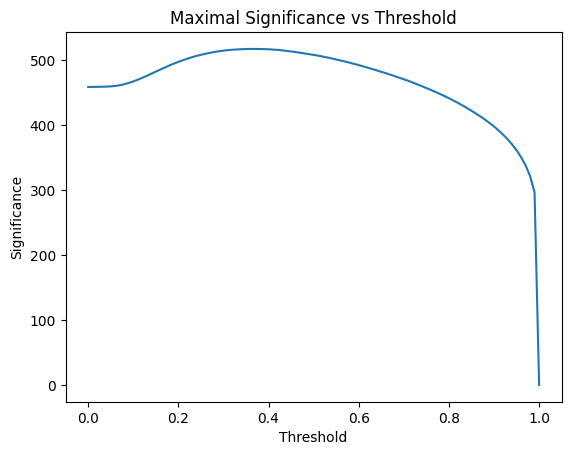

Max significance: 516.7779602844885
Best threshold: 0.36363636363636365


In [17]:
# Use Logistic Regression with all features (best performer)
best_clf = LogisticRegression(max_iter=1000)
best_clf.fit(X_Train_sub[VarNames[1:]], y_Train_sub)

# Get predicted probabilities on test set
y_scores = best_clf.predict_proba(X_Test[VarNames[1:]])[:,1]

# Compute significance for different thresholds
thresholds = np.linspace(0, 1, 100)

significances = []
for t in thresholds:
    y_pred = (y_scores > t).astype(int)
    N_S = np.sum((y_pred == 1) & (y_Test == 1))  # true signal passing cut
    N_B = np.sum((y_pred == 1) & (y_Test == 0))  # true background passing cut
    if (N_S + N_B) > 0:
        sig = N_S / np.sqrt(N_S + N_B)
    else:
        sig = 0
    significances.append(sig)

# Plot significance vs threshold
plt.figure()
plt.plot(thresholds, significances)
plt.xlabel('Threshold')
plt.ylabel('Significance')
plt.title('Maximal Significance vs Threshold')
plt.show()

print("Max significance:", max(significances))
print("Best threshold:", thresholds[np.argmax(significances)])

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

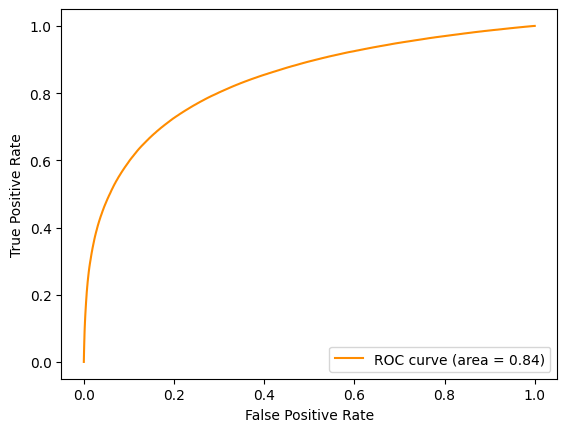

In [20]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [19]:
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)

# Train best classifier (Logistic Regression with all features)
best_clf = LogisticRegression(max_iter=1000)
best_clf.fit(X_Train_sub[VarNames[1:]], y_Train_sub)

# Get predictions and scores
y_pred = best_clf.predict(X_Test[VarNames[1:]])
y_scores = best_clf.predict_proba(X_Test[VarNames[1:]])[:,1]

# ROC/AUC
fpr, tpr, thresholds = roc_curve(y_Test, y_scores)
roc_auc = auc(fpr, tpr)

# TPR and FPR at default threshold
TPR = recall_score(y_Test, y_pred)
FPR = 1 - recall_score(1 - y_Test, 1 - y_pred)

# All metrics
precision = precision_score(y_Test, y_pred)
recall = recall_score(y_Test, y_pred)
f1 = f1_score(y_Test, y_pred)
accuracy = accuracy_score(y_Test, y_pred)

# Max significance from Part c
N_S_total = np.sum(y_Test == 1)
N_B_total = np.sum(y_Test == 0)
N_S = tpr[1:] * N_S_total
N_B = fpr[1:] * N_B_total
max_sig = np.max(np.where((N_S + N_B) > 0, N_S / np.sqrt(N_S + N_B), 0))

# Print table
print(f"{'Metric':<20} {'Value':.>10}")
print("-" * 30)
print(f"{'TPR':<20} {TPR:>10.4f}")
print(f"{'FPR':<20} {FPR:>10.4f}")
print(f"{'AUC':<20} {roc_auc:>10.4f}")
print(f"{'Precision':<20} {precision:>10.4f}")
print(f"{'Recall':<20} {recall:>10.4f}")
print(f"{'F1 Score':<20} {f1:>10.4f}")
print(f"{'Accuracy':<20} {accuracy:>10.4f}")
print(f"{'Max Significance':<20} {max_sig:>10.4f}")

Metric               .....Value
------------------------------
TPR                      0.6778
FPR                      0.1179
AUC                      0.8583
Precision                0.8294
Recall                   0.6778
F1 Score                 0.7460
Accuracy                 0.7885
Max Significance       516.8044
